In [90]:
#импортируем библиотеки
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from math import ceil


# Описание проекта и данных
В данном проекте проводится А/B тестирование данных об удержании пользователей игры Cookie Cats (данные взяты с kaggle https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing). Структура данных:

*   userid - id пользователя;
*   version	-версия игры (либо выход на 30 уровне, либо на 40);
*   sum_gamerounds - общее количество уровней, пройденных пользователем;
*   retention_1 - удержание пользователей на 1 день после выхода;
*   retention_7 - удержание пользователей на 7 день после выхода.
В рамках проекта предлагается провести EDA, А/B тестирования для проверки гипотез:
1) перенос выхода с 30 на 40 уровень поднимет retention пользователей в 1 день на 1%;
2) перенос выхода с 30 на 40 уровень поднимет retention пользователей в 7 день на 1%;
3) перенос выхода с 30 на 40 уровень поднимет sum_gamerounds на 10%.


# EDA

In [91]:
#скачиваем данные с kaggle
path = kagglehub.dataset_download("yufengsui/mobile-games-ab-testing")

data = pd.read_csv(path+'/cookie_cats.csv')

Using Colab cache for faster access to the 'mobile-games-ab-testing' dataset.


In [92]:
data

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


Проверяем пропуски в данных

In [93]:
data.isna().sum() #пропусков в данных нет

,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


Проверяем дубликаты

In [94]:
data.duplicated().sum() #дубликатов нет

np.int64(0)

Данные уже агрегированы по пользователям — одна строка = один пользователь.

In [95]:
data['userid'].duplicated().sum()

np.int64(0)

Посомтрим на распределение пользователей по версиям

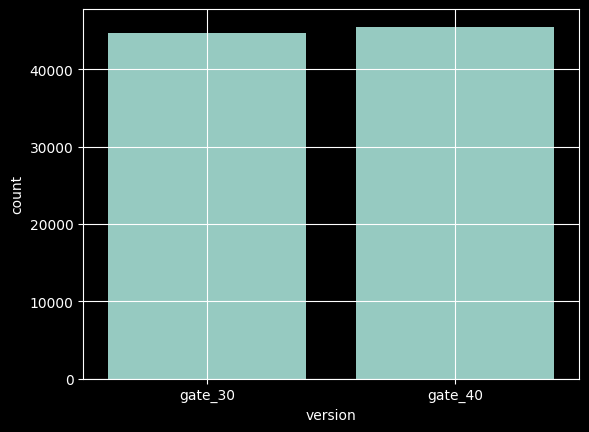

In [96]:
plt.style.use('dark_background') #видим, что количество пользователей в каждой версии примерно равное
sns.countplot(x=data['version'])
plt.grid()

Далее разделим данные на контрольные (version == gate_30) и тестовую (version == gate_40) выборки.

In [97]:
control=data[data['version']=='gate_30']
test=data[data['version']=='gate_40']

Посмотрим на метрики retention_1, retention_7 и sum_gamerounds на контрольных данных

In [98]:
round(control['retention_1'].mean() * 100, 2)

np.float64(44.82)

In [99]:
round(control['retention_7'].mean() * 100, 2)

np.float64(19.02)

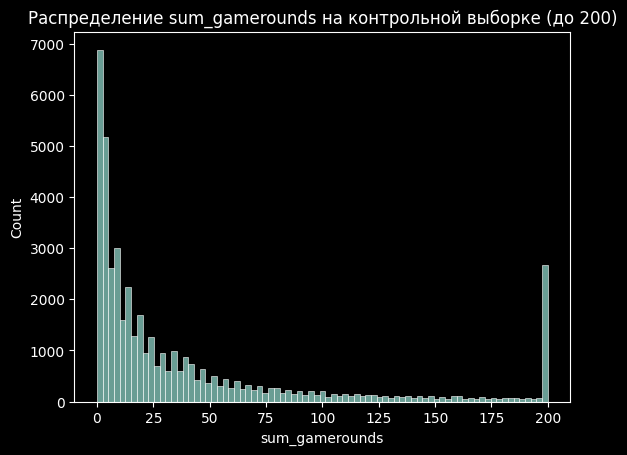

In [100]:
sns.histplot(control['sum_gamerounds'].clip(upper=200))
plt.title('Распределение sum_gamerounds на контрольной выборке (до 200)')
plt.show()

Видим, что sum_gamerounds имеет сильно смещенное распределение

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


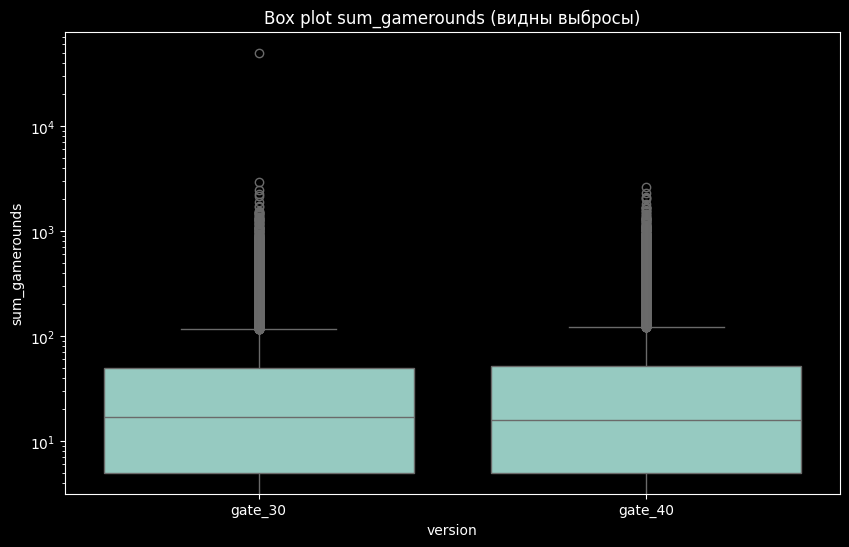


Пользователей, прошедших >1000 уровней: 116 (0.13%)
Максимальное значение: 49854

Среднее sum_gamerounds: 51.87
Медиана sum_gamerounds: 16.00
Разница: 35.87

Есть сильные выбросы, влияющие на среднее


In [101]:
print(data['sum_gamerounds'].describe())

# 2. Простой boxplot для визуализации выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(x='version', y='sum_gamerounds', data=data)
plt.title('Box plot sum_gamerounds (видны выбросы)')
plt.yscale('log')  # логарифмическая шкала, чтобы увидеть всю картину
plt.show()

# 3. Подсчет экстремальных значений (больше 1000 уровней)
extreme_users = data[data['sum_gamerounds'] > 1000]
print(f"\nПользователей, прошедших >1000 уровней: {len(extreme_users)} ({len(extreme_users)/len(data)*100:.2f}%)")
print(f"Максимальное значение: {data['sum_gamerounds'].max()}")

# 4. Сравнение среднего и медианы (если они сильно отличаются - есть выбросы)
print(f"\nСреднее sum_gamerounds: {data['sum_gamerounds'].mean():.2f}")
print(f"Медиана sum_gamerounds: {data['sum_gamerounds'].median():.2f}")
print(f"Разница: {data['sum_gamerounds'].mean() - data['sum_gamerounds'].median():.2f}")

if data['sum_gamerounds'].mean() > data['sum_gamerounds'].median() * 2:
    print("\nЕсть сильные выбросы, влияющие на среднее")
else:
    print("\nВыбросы не критичны")

Посмотрим то же самое на тестовых данных

In [102]:
round(test['retention_1'].mean() * 100, 2)

np.float64(44.23)

In [103]:
round(test['retention_7'].mean() * 100, 2)

np.float64(18.2)

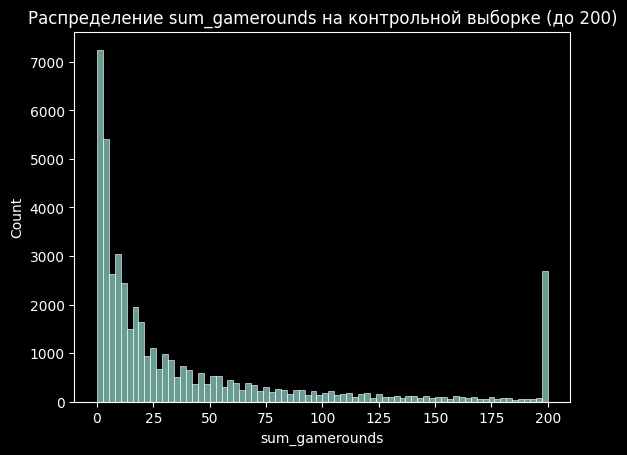

In [104]:
sns.histplot(test['sum_gamerounds'].clip(upper=200))
plt.title('Распределение sum_gamerounds на контрольной выборке (до 200)')
plt.show()

# Тестирование retention_1


*   H0: Retention в тестовой группе (gate_40) равен retention в контрольной группе (gate_30);
*   H1: Retention в тестовой группе (gate_40) отличается от retention в контрольной группе (gate_30) (двусторонний тест).

Будем использовать следюущим паракметры критерия:

*   a = 0.05
*   мощность теста = 0.8



## Расчет MDE
Чтобы понять, хватит ли нам мощности теста для обнаружения желаемого эффекта, посчитаем MDE, который мы можем обнаружить с имеющимися данными.

Расчет MDE для двухвыборочного t-теста (или теста пропорций).
Используем стандартную формулу для расчета эффекта при заданной мощности.
Коэффициенты для alpha=0.05 (двусторонний) и power=0.80.
Z_score для alpha/2 (1.96) и для beta (0.84).
Формула MDE (для пропорций через стандартное отклонение).
MDE = (z_alpha + z_beta) * sqrt( (p0*(1-p0) + p1*(1-p1)) / n).

In [105]:
def get_mde(historical_retention, total_users_in_test, metric):
  total_users_in_test = len(data) # Сколько всего юзеров пойдет в эксперимент (и тест и контроль)
  proportion_control = len(historical_retention)/total_users_in_test      # Обычно 50% в контроле
  proportion_treatment = 1-proportion_control     # и 50% в тесте

  alpha = 0.05  # Уровень значимости (5%)
  power = 0.80  # Мощность (80%)

  baseline_conversion = np.mean(historical_retention)

  std_dev = np.std(historical_retention, ddof=1) # ddof=1 для несмещенной оценки (выборочное СКО)
  print(f"Базовый {metric}: {baseline_conversion:.2%}")
  print(f"Стандартное отклонение (историческое): {std_dev:.4f}")

  n = total_users_in_test * proportion_control

  z_alpha = stats.norm.ppf(1 - alpha/2)
  z_beta = stats.norm.ppf(power)

  se = np.sqrt( (baseline_conversion * (1 - baseline_conversion)) / n )

  mde_absolute = (z_alpha + z_beta) * se * np.sqrt(2) # *sqrt(2) т.к. две группы

  mde_relative = (mde_absolute / baseline_conversion) * 100

  print(f"Размер групп (n): {n:.0f} пользователей")
  print(f"MDE (абсолютный): {mde_absolute:.4f} ({mde_absolute*100:.2f} процентных пунктов)")
  print(f"MDE (относительный): {mde_relative:.2f}% от базового значения")
  print(f"Сможем обнаружить рост {metric} с {baseline_conversion:.2%} до {baseline_conversion + mde_absolute:.2%}")
  print(f"Сможем обнаружить падение: с {baseline_conversion:.2%} до {baseline_conversion - mde_absolute:.2%}")

In [106]:
get_mde(control['retention_1'], len(data), 'retention_1')

Базовый retention_1: 44.82%
Стандартное отклонение (историческое): 0.4973
Размер групп (n): 44700 пользователей
MDE (абсолютный): 0.0093 (0.93 процентных пунктов)
MDE (относительный): 2.08% от базового значения
Сможем обнаружить рост retention_1 с 44.82% до 45.75%
Сможем обнаружить падение: с 44.82% до 43.89%


Вывод: MDE составляет 0.93 процентных пункта, что меньше целевого эффекта в 1 п.п., следовательно, мощности теста достаточно

## АА тест

Для оценки критерия проведем АА тест на контрольной выборке

In [107]:
#функция для расчета доверительных интервалов
def proportion_ci(pvalue_vector, alpha=0.05):
    pvalue_vector = np.asarray(pvalue_vector).flatten()
    n = len(pvalue_vector)
    count = np.sum(pvalue_vector < alpha)
    p = count / n
    left_bound = p - np.sqrt(p * (1 - p) / n) * stats.norm.ppf(1-alpha/2)
    right_bound = p + np.sqrt(p * (1 - p) / n) * stats.norm.ppf(1-alpha/2)
    return p, left_bound, right_bound

In [108]:
def plot_comparison_with_uniform(p_value_vector, title, color='skyblue'):
    p, left_boundary, right_boundary = proportion_ci(p_value_vector)
    print(f"Ошибка I рода: {round(p, 4)},\nCI для oшибки I рода: [{round(left_boundary, 4)}, {round(right_boundary, 4)}]")

    fig1, ax1 = plt.subplots(1, 3, figsize=(17, 5))

    # --- 1. Гистограмма P-value ---
    ax1[0].hist(p_value_vector, bins=30, edgecolor='black', alpha=0.7, color=color)
    ax1[0].set_title(
        f'Ошибка I рода: {round(np.sum(np.array(p_value_vector) < 0.05) / len(p_value_vector), 3)}'
    )
    ax1[0].set_xlabel('P-value')
    ax1[0].set_ylabel('Частота')

    # --- 2. QQ-график ---
    stats.probplot(p_value_vector, dist=stats.uniform, plot=ax1[1])
    ax1[1].get_lines()[1].set_linestyle('--')
    ax1[1].set_title(f'{title} (QQ-график)')

    # --- 3. Эмпирическая функция распределения ---
    pvals_sorted = np.sort(p_value_vector)
    n = len(pvals_sorted)
    ecdf = np.arange(1, n+1) / n

    x_uniform = np.linspace(0, 1, 200)
    cdf_uniform = x_uniform

    ax1[2].step(pvals_sorted, ecdf, where='post', label='Эмпирическая ФР', color=color)
    ax1[2].plot(x_uniform, cdf_uniform, color='red', linestyle='--', label='Теоретическая CDF $U[0,1]$')

    # --- Тест Колмогорова-Смирнова ---
    ks_statistic, ks_p_value = stats.kstest(p_value_vector, 'uniform', args=(0, 1))
    print(f'Статистика Колмогорова-Смирнова: {round(ks_statistic, 4)}, pvalue для сравнения ЭФР с равномерным: {round(ks_p_value, 4)}')
    if ks_p_value < 0.05:
        print("Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)")
    else:
        print("Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)")

    ax1[2].set_title('Эмпирическая и теоретическая ФР')
    ax1[2].set_xlabel('p-value')
    ax1[2].set_ylabel('F(p-value)')
    ax1[2].legend(loc="lower right")
    ax1[2].text(
        0.05, 0.9,
        f"KS: stat={ks_statistic:.3f}\np={ks_p_value:.3f}",
        transform=ax1[2].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle="round", fc="w", alpha=0.5)
    )

    plt.tight_layout()
    plt.show()

In [109]:
p_values_retention_1 = []

for _ in range(5000):
    sample = control.sample(frac=1)
    split = len(sample) // 2
    a = sample.iloc[:split]
    b = sample.iloc[split:]

    # Считаем количество успехов (True) в каждой группе
    successes_a = a['retention_1'].sum()
    successes_b = b['retention_1'].sum()

    # Размеры групп
    nobs_a = len(a)
    nobs_b = len(b)

    # Z-тест для пропорций
    stat, p = proportions_ztest([successes_a, successes_b],
                                [nobs_a, nobs_b])

    p_values_retention_1.append(p)

Ошибка I рода: 0.0514,
CI для oшибки I рода: [0.0453, 0.0575]
Статистика Колмогорова-Смирнова: 0.0162, pvalue для сравнения ЭФР с равномерным: 0.1454
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


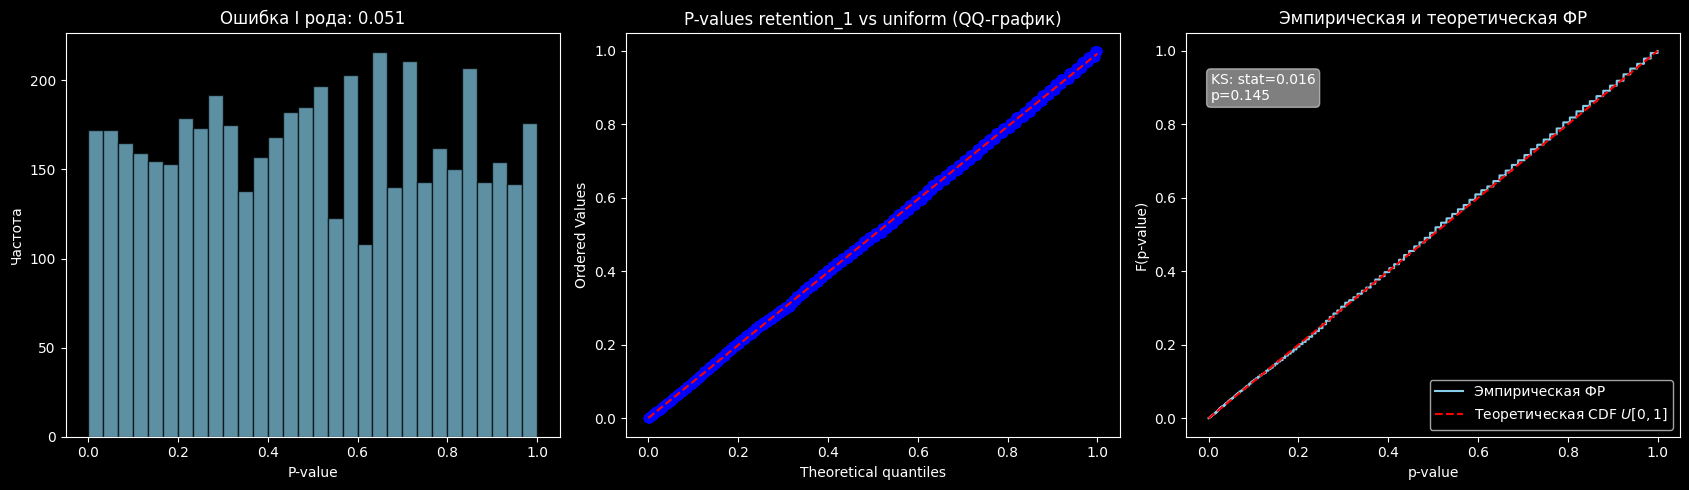

In [110]:
plot_comparison_with_uniform(np.array(p_values_retention_1), 'P-values retention_1 vs uniform', color='skyblue')

Как видим p-value имеет нормальное распределение по всем тестам, поэтому критерий приемлем для теста

## А/B тест

Используем двусторонний z-test.
Ошибка a = 0.05

In [111]:
round(test['retention_1'].mean(), 2)

np.float64(0.44)

Мы видим, что среднее у тестовой группы меньше, чем у контрольной группы

In [112]:
def ab_test(metric):
    n_gate30 = len(control)
    n_gate40 = len(test)
    conv_gate30 = control[metric].sum()
    conv_gate40 = test[metric].sum()

    stat, p =proportions_ztest([conv_gate30, conv_gate40],
                                [n_gate30, n_gate40])
    print(f"{metric}: p-value = {p:.4f}")

In [113]:
ab_test('retention_1')

retention_1: p-value = 0.0744


P-value >0.05, следовательно нет оснований отвергать нулевую гипотезу. Нет достаточных статистических оснований утверждать, что смещение выхода на 40 уровень приводит к изменению метрики retention_1.

# Тестирование retention_7

*  H0: Retention в тестовой группе (gate_40) равен retention в контрольной группе (gate_30);
*  H1: Retention в тестовой группе (gate_40) отличается от retention в контрольной группе (gate_30) (двусторонний тест).

Будем использовать следюущие параметры критерия:

*   a = 0.05
*   мощность теста = 0.8


## Рассчет MDE

In [114]:
get_mde(control['retention_7'], len(data), 'retention_7')

Базовый retention_7: 19.02%
Стандартное отклонение (историческое): 0.3925
Размер групп (n): 44700 пользователей
MDE (абсолютный): 0.0074 (0.74 процентных пунктов)
MDE (относительный): 3.87% от базового значения
Сможем обнаружить рост retention_7 с 19.02% до 19.76%
Сможем обнаружить падение: с 19.02% до 18.28%


Вывод: MDE составляет 0.74 процентных пункта, что меньше целевого эффекта в 1 п.п., следовательно, мощности теста достаточно

## АА тест

In [115]:
p_values_retention_7 = []

for _ in range(5000):
    sample = control.sample(frac=1)
    split = len(sample) // 2
    a = sample.iloc[:split]
    b = sample.iloc[split:]

    # Считаем количество успехов (True) в каждой группе
    successes_a = a['retention_7'].sum()
    successes_b = b['retention_7'].sum()

    # Размеры групп
    nobs_a = len(a)
    nobs_b = len(b)

    # Z-тест для пропорций
    stat, p = proportions_ztest([successes_a, successes_b],
                                [nobs_a, nobs_b])

    p_values_retention_7.append(p)

Ошибка I рода: 0.051,
CI для oшибки I рода: [0.0449, 0.0571]
Статистика Колмогорова-Смирнова: 0.0177, pvalue для сравнения ЭФР с равномерным: 0.0862
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


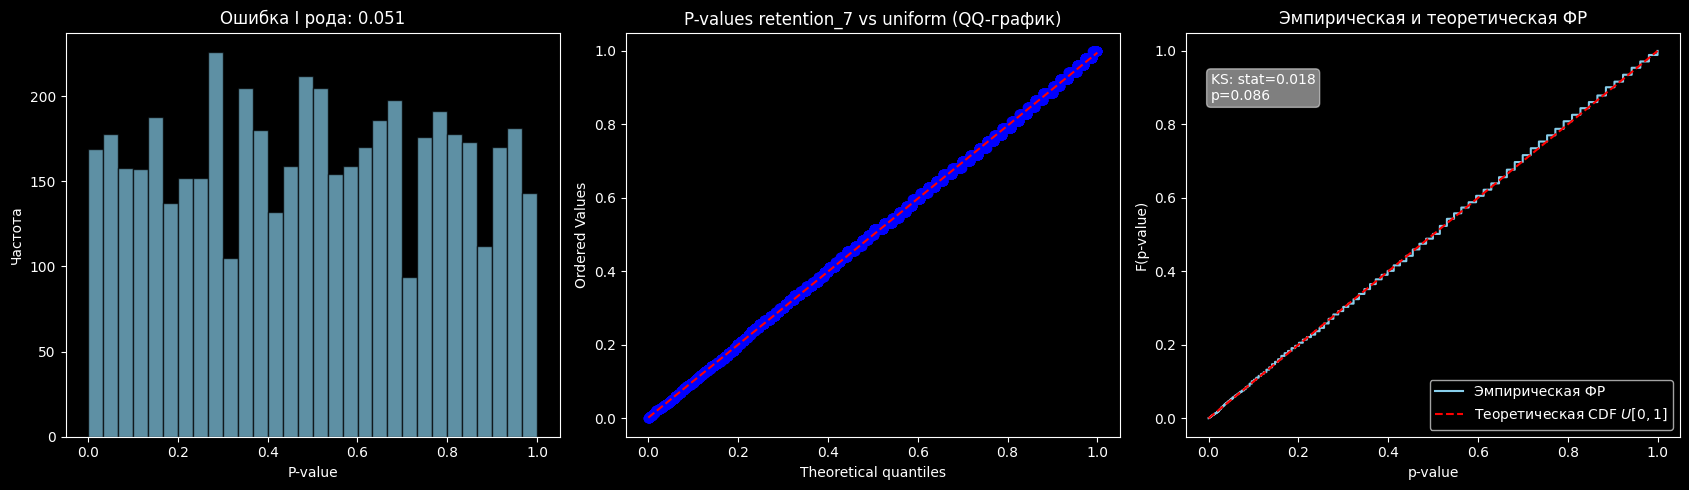

In [116]:
plot_comparison_with_uniform(np.array(p_values_retention_7), 'P-values retention_7 vs uniform', color='skyblue')

Как видим p-value имеет нормальное распределение по всем тестам, поэтому критерий приемлем для теста

## A/B тест

Используем двусторонний z-test. Ошибка a = 0.05

In [117]:
round(test['retention_7'].mean(), 2)

np.float64(0.18)

In [118]:
ab_test('retention_7')

retention_7: p-value = 0.0016


"P-value = 0.0016 < 0.05. Мы отвергаем нулевую гипотезу об отсутствии различий. Обнаружено статистически значимое снижение retention_7 в тестовой группе по сравнению с контрольной (18.2% против 19.02%)."

# Тестирование sum_gamerounds

*   H0: Среднее количество пройденных уровней в тестовой группе равно контрольной;
*   H1: Среднее количество пройденных уровней в тестовой группе отличается от контрольной.




## Рассчет MDE

In [119]:
def get_mde_continuous(historical_values, total_users_in_test, metric_name='metric'):

    n_per_group = total_users_in_test / 2

    alpha = 0.05
    power = 0.80

    baseline_mean = np.mean(historical_values)
    baseline_std = np.std(historical_values, ddof=1)

    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)

    standard_error = baseline_std * np.sqrt(2 / n_per_group)
    mde_absolute = (z_alpha + z_beta) * standard_error
    mde_relative = (mde_absolute / baseline_mean) * 100

    print(f"Базовое среднее {metric_name}: {baseline_mean:.2f}")
    print(f"Стандартное отклонение: {baseline_std:.2f}")
    print(f"Размер групп (n): {n_per_group:.0f} пользователей")
    print(f"MDE (абсолютный): {mde_absolute:.2f}")
    print(f"MDE (относительный): {mde_relative:.1f}% от базового значения")
    print(f"Сможем обнаружить рост {metric_name} с {baseline_mean:.2f} до {baseline_mean + mde_absolute:.2f}")
    print(f"Сможем обнаружить падение {metric_name} с {baseline_mean:.2f} до {baseline_mean - mde_absolute:.2f}")

In [120]:
get_mde_continuous(control['sum_gamerounds'], len(test), metric_name='sum_gamerounds')

Базовое среднее sum_gamerounds: 52.46
Стандартное отклонение: 256.72
Размер групп (n): 22744 пользователей
MDE (абсолютный): 6.74
MDE (относительный): 12.9% от базового значения
Сможем обнаружить рост sum_gamerounds с 52.46 до 59.20
Сможем обнаружить падение sum_gamerounds с 52.46 до 45.71


Мощности критерия недостаточно, чтобы оценить изменение метрики на 10%. Мы не сможем обнаружить этот эффект. Минимальный эффект, который мы сможем обнаружить это 12.9%. Скорректируем нашу задачу и посмотрим, есть ли эффект на уровне 12.9%

## AA тест

Поскольку на этапе EDA мы наблюдали сильное смещение распределения метрики sum_gamerounds, для анализа мы используем U-тест Манна-Уитни

Ошибка I рода: 0.047,
CI для oшибки I рода: [0.0339, 0.0601]
Статистика Колмогорова-Смирнова: 0.0184, pvalue для сравнения ЭФР с равномерным: 0.8822
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


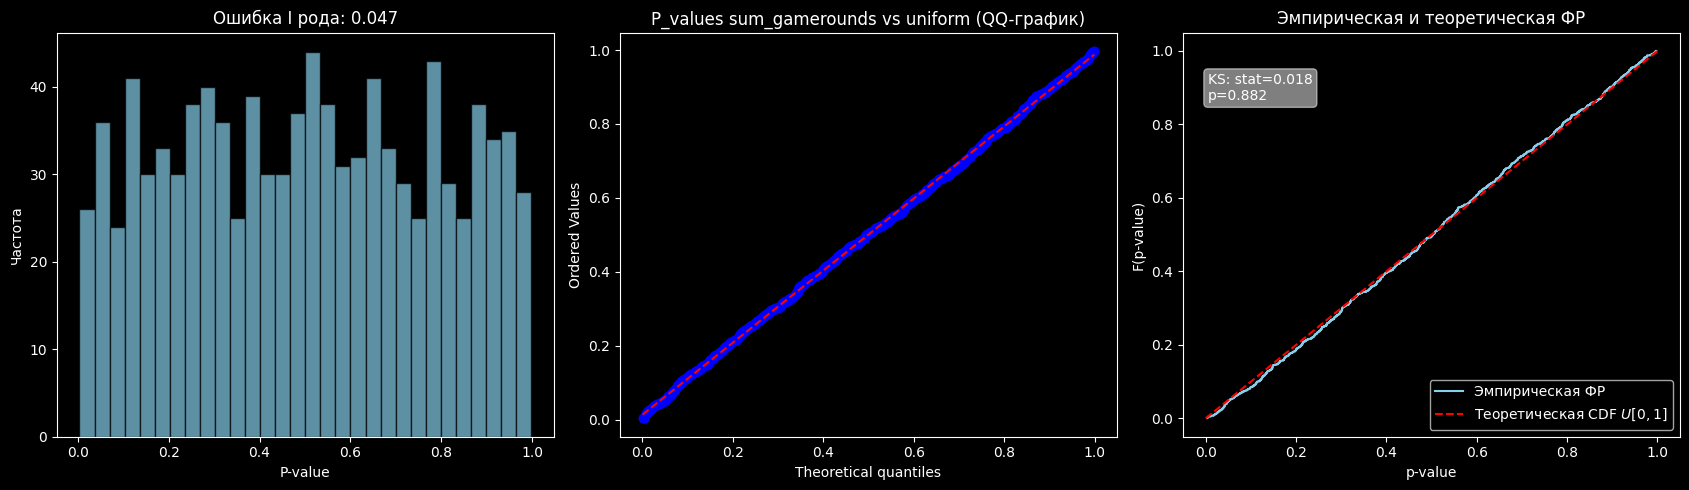

In [121]:
p_values_sum_gamerounds = []

for _ in range(1000):
    sample = control.sample(frac=1)
    split = len(sample) // 2
    a = sample.iloc[:split]
    b = sample.iloc[split:]
    stat, p = stats.mannwhitneyu(a['sum_gamerounds'], b['sum_gamerounds'])

    p_values_sum_gamerounds.append(p)

plot_comparison_with_uniform(np.array(p_values_sum_gamerounds), 'P_values sum_gamerounds vs uniform', color='skyblue')


Как видим p-value имеет нормальное распределение по всем тестам, поэтому критерий приемлем для теста

## A/B тест

Как и для АА теста, используем для А/B используем U-тест Манна-Уитни

In [122]:
stat, p_value = stats.mannwhitneyu(control['sum_gamerounds'], test['sum_gamerounds'], alternative='two-sided')

print(f"Статистика U: {stat:.0f}")
print(f"p-value: {p_value:.4f}")


Статистика U: 1024331250
p-value: 0.0502


 p-value = 0.0502. Это очень близко к порогу 0.05. Стоит отметить этот "пограничный" результат. Строго говоря, при alpha=0.05 мы не отвергаем H0, но результат близок к значимому. Это может указывать на наличие слабого эффекта, который мы не смогли обнаружить из-за недостаточной мощности (MDE как раз был 12.9%, а мы искали 10%).

# Вывод

В ходе проекта был проведен анализ результатов A/B-теста, целью которого была оценка влияния переноса внутриигрового "ворота" (gate) с 30-го на 40-й уровень на ключевые метрики удержания игроков (retention) и их активность (количество пройденных уровней).

Основные этапы и результаты:

Разведывательный анализ (EDA) показал, что данные не содержат пропусков и дубликатов, а группы контроля (gate_30) и теста (gate_40) сбалансированы по размеру. Было выявлено, что метрика sum_gamerounds имеет сильно скошенное распределение с выбросами, что определило выбор непараметрического критерия Манна-Уитни для ее анализа.

Оценка мощности теста (MDE):

Для метрики retention_1 расчетный MDE составил 0.93 п.п., что меньше целевого эффекта в 1 п.п. Мощности теста достаточно для обнаружения желаемого эффекта.

Для метрики retention_7 расчетный MDE составил 0.74 п.п., что также меньше целевого эффекта в 1 п.п. Мощности теста достаточно.

Для метрики sum_gamerounds MDE составил 12.9% от среднего значения. Это превышает целевой эффект в 10%. Таким образом, мощности теста недостаточно для обнаружения 10%-го изменения. Тест позволяет обнаружить только более сильный эффект (относительное изменение более чем на 12.9%).

Валидация критерия (AA-тест) подтвердила, что выбранные статистические критерии (z-тест для пропорций и U-тест Манна-Уитни) работают корректно: распределение p-value в AA-тесте близко к равномерному, а уровень ошибки I рода не превышает номинальный (0.05).

Результаты A/B-теста:

retention_1 (удержание на 1-й день): Статистически значимых различий между группами не обнаружено (p-value = 0.074). Мы не можем утверждать, что перенос "ворота" повлиял на долю пользователей, вернувшихся в игру на следующий день.

retention_7 (удержание на 7-й день): Обнаружено статистически значимое различие между группами (p-value = 0.0016). В тестовой группе (gate_40) удержание на 7-й день оказалось ниже (18.2%), чем в контрольной (19.02%). Это говорит о негативном влиянии изменения на долгосрочное удержание пользователей.

sum_gamerounds (количество пройденных уровней): Статистически значимых различий на уровне α=0.05 не обнаружено (p-value = 0.0502). Однако полученное значение находится на границе статистической значимости, что в сочетании с недостаточной мощностью теста (MDE > 10%) не позволяет сделать однозначный вывод об отсутствии эффекта. Можно говорить о том, что убедительных доказательств влияния на суммарную активность игроков нет.

Итоговое заключение:

Перенос внутриигрового "ворота" с 30-го на 40-й уровень негативно сказался на долгосрочном удержании игроков (retention_7). Влияние на краткосрочное удержание (retention_1) и на общую активность игроков (sum_gamerounds) статистически не подтвердилось. На основании полученных данных, внедрение изменения не рекомендуется.